# 4. Análisis bivariado

Este capítulo cuantifica la relación entre cada predictor y la readmisión temprana. Como en el capítulo anterior, se usa **solo el conjunto de entrenamiento**.

Cuatro principios guían los contrastes.

1. **La significancia no basta.** Con casi ochenta mil encuentros, diferencias irrelevantes en la práctica alcanzan valores p muy pequeños. Cada contraste se acompaña de una medida de tamaño del efecto.
2. **Se corrige por comparaciones múltiples.** Se evalúan casi cuarenta variables; sin corrección, se esperaría alrededor de un falso positivo por cada veinte contrastes solo por azar. Se aplica la corrección de Holm-Bonferroni dentro de cada familia de contrastes.
3. **Las observaciones no son independientes.** El capítulo 3 mostró que un mismo paciente aporta varios encuentros y que el tamaño de muestra efectivo es menor que el número de filas. La sección 4.7 repite los contrastes principales bajo dos esquemas robustos a esa dependencia.
4. **La asociación se mide de tres formas complementarias**, porque cada una ve un aspecto distinto: un contraste de hipótesis (¿hay diferencia?), un tamaño de efecto (¿cuán grande?) y una medida de capacidad discriminante —el AUC univariado y la información mutua— que es directamente comparable con el desempeño del modelo base del capítulo 7. Esa última es la que permite responder a la pregunta que de verdad importa: cuánto de lo que consigue un modelo ya estaba en un solo predictor.

In [1]:
from config import *
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

try:
    from myst_nb import glue as _glue
except ImportError:  # el notebook sigue siendo ejecutable fuera de Jupyter Book
    def _glue(clave, valor, display=False):
        return None


def anotar(clave, valor):
    """Publica un valor para poder citarlo en el texto del capítulo.

    Las celdas de texto lo recuperan con el rol ``{glue:text}``. Ver la
    justificación en el capítulo 3.
    """
    _glue(clave, str(valor), display=False)
    return valor


roles = roles_variables()
OBJETIVO = roles["objetivo"]
IDENTIFICADOR = roles["identificador"]
NUMERICAS = roles["numericas"] + roles["ordinales"]
CATEGORICAS = roles["categoricas"]
BINARIAS = roles["binarias"]
ETIQUETAS_EDAD = {int(k): v for k, v in roles["etiquetas_edad"].items()}
PREDICTORES = NUMERICAS + BINARIAS + CATEGORICAS

train = leer_tabla("diabetes_train")
assert train.isna().sum().sum() == 0, "El conjunto cargado tiene faltantes"

objetivo = train[OBJETIVO].to_numpy()
tasa_global = 100 * objetivo.mean()
grupos = train[IDENTIFICADOR]

anotar("c4_encuentros", f"{len(train):,}")
anotar("c4_tasa", f"{tasa_global:.2f}")
print(f"Entrenamiento: {len(train):,} encuentros de {grupos.nunique():,} "
      f"pacientes | tasa de readmisión temprana: {tasa_global:.2f} %")

Entrenamiento: 79,473 encuentros de 56,036 pacientes | tasa de readmisión temprana: 11.39 %


In [2]:
def correccion_holm(valores_p):
    """Corrección de Holm-Bonferroni para comparaciones múltiples.

    Controla la tasa de error familiar de forma uniformemente más potente
    que Bonferroni y sin supuestos sobre la dependencia entre contrastes.

    Parameters
    ----------
    valores_p : array_like
        Valores p sin corregir.

    Returns
    -------
    numpy.ndarray
        Valores p ajustados, monótonos y acotados en 1.
    """
    p = np.asarray(valores_p, dtype=float)
    m = len(p)
    orden = np.argsort(p)
    ajustados = np.empty(m)
    maximo = 0.0
    for i, indice in enumerate(orden):
        maximo = max(maximo, (m - i) * p[indice])
        ajustados[indice] = min(1.0, maximo)
    return ajustados


def delta_cliff(grupo_a, grupo_b):
    """Delta de Cliff a partir del estadístico U de Mann-Whitney.

    Mide la diferencia entre la probabilidad de que una observación del
    primer grupo supere a una del segundo y la probabilidad inversa. Es
    robusta a la forma de la distribución y maneja empates correctamente,
    ya que el estadístico U los pondera con medio punto.

    Returns
    -------
    float
        Valor en [-1, 1]; 0 indica ausencia de diferencia estocástica.
    """
    u = stats.mannwhitneyu(grupo_a, grupo_b).statistic
    return 2 * u / (len(grupo_a) * len(grupo_b)) - 1


def magnitud_cliff(delta):
    """Clasifica la delta de Cliff según los umbrales convencionales."""
    d = abs(delta)
    if d < 0.147:
        return "Insignificante"
    if d < 0.330:
        return "Pequeño"
    if d < 0.474:
        return "Mediano"
    return "Grande"


def v_cramer(contingencia):
    """V de Cramér con la corrección por sesgo de Bergsma.

    La corrección es necesaria con muestras grandes y tablas de muchas
    categorías, donde la V sin corregir sobrestima la asociación.

    Returns
    -------
    float
        Valor en [0, 1]; 0 indica independencia.
    """
    chi2 = stats.chi2_contingency(contingencia).statistic
    n = contingencia.values.sum()
    phi2 = chi2 / n
    r, k = contingencia.shape
    phi2_corregido = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corregido = r - (r - 1) ** 2 / (n - 1)
    k_corregido = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2_corregido /
                   max(1e-12, min(k_corregido - 1, r_corregido - 1)))


def intervalo_wilson(exitos, total, confianza=0.95):
    """Intervalo de confianza de Wilson para una proporción.

    Preferible al intervalo normal cuando la proporción es pequeña o el
    tamaño del grupo es reducido, situaciones en las que el intervalo
    clásico puede incluir valores negativos.

    Returns
    -------
    tuple of float
        Límites inferior y superior de la proporción.
    """
    if total == 0:
        return (np.nan, np.nan)
    z = stats.norm.ppf(1 - (1 - confianza) / 2)
    p = exitos / total
    centro = (p + z ** 2 / (2 * total)) / (1 + z ** 2 / total)
    margen = (z / (1 + z ** 2 / total)) * np.sqrt(
        p * (1 - p) / total + z ** 2 / (4 * total ** 2))
    return centro - margen, centro + margen

El análisis se hace sobre los {glue:text}`c4_encuentros` encuentros de entrenamiento, con una tasa de readmisión temprana del {glue:text}`c4_tasa` %.

## 4.1. Variables numéricas frente al desenlace

Al no cumplirse la normalidad (capítulo 3), la comparación entre readmitidos y no readmitidos se hace con la **U de Mann-Whitney**, que contrasta si una variable tiende a tomar valores mayores en un grupo que en el otro sin suponer una forma distribucional.

Se reportan tres medidas complementarias de la magnitud.

- La **correlación biserial puntual** es la correlación de Pearson entre el predictor y el indicador binario, e informa sobre asociación lineal.
- La **delta de Cliff** mide la probabilidad de que una observación de un grupo supere a una del otro, es robusta a la forma de la distribución y se interpreta con los umbrales de 0.147 (pequeño), 0.330 (mediano) y 0.474 (grande).
- El **AUC univariado** es el área bajo la curva ROC que se obtendría usando el predictor por sí solo como puntuación de riesgo. No es una medida independiente de la anterior: para un predictor continuo se cumple exactamente que `AUC = (δ + 1) / 2`, de modo que ambas contienen la misma información. Se reporta porque está en la misma escala que la métrica principal del proyecto, y eso permite comparar directamente cada predictor con el desempeño del modelo base del capítulo 7.

In [3]:
filas = []
for columna in NUMERICAS + BINARIAS:
    grupo_1 = train.loc[train[OBJETIVO] == 1, columna]
    grupo_0 = train.loc[train[OBJETIVO] == 0, columna]
    delta = delta_cliff(grupo_1, grupo_0)
    filas.append({
        "variable": columna,
        "mediana (no readm.)": grupo_0.median(),
        "mediana (readm.)": grupo_1.median(),
        "media (no readm.)": grupo_0.mean(),
        "media (readm.)": grupo_1.mean(),
        "p (Mann-Whitney)": stats.mannwhitneyu(grupo_1, grupo_0).pvalue,
        "r biserial": stats.pointbiserialr(
            train[OBJETIVO], train[columna]).statistic,
        "delta de Cliff": delta,
        # Identidad exacta entre la delta de Cliff y el AUC de un predictor
        # usado por sí solo como puntuación de riesgo.
        "AUC univariado": (delta + 1) / 2,
        "magnitud del efecto": magnitud_cliff(delta),
    })

asociacion_num = pd.DataFrame(filas).set_index("variable")
asociacion_num["p (Holm)"] = correccion_holm(asociacion_num["p (Mann-Whitney)"])
asociacion_num["significativa (Holm)"] = np.where(
    asociacion_num["p (Holm)"] < 0.05, "Sí", "No")
asociacion_num = asociacion_num.reindex(
    asociacion_num["delta de Cliff"].abs().sort_values(ascending=False).index)

# Verificación de la identidad citada en el texto, sobre la variable con
# mayor efecto: el AUC calculado con scikit-learn debe coincidir.
mejor = asociacion_num.index[0]
auc_directo = roc_auc_score(train[OBJETIVO], train[mejor])
assert abs(auc_directo - asociacion_num.loc[mejor, "AUC univariado"]) < 1e-9

anotar("c4_mejor_num", mejor)
anotar("c4_mejor_delta", f"{asociacion_num.loc[mejor, 'delta de Cliff']:.3f}")
anotar("c4_mejor_auc", f"{asociacion_num.loc[mejor, 'AUC univariado']:.3f}")
anotar("c4_num_signif", int(
    (asociacion_num["significativa (Holm)"] == "Sí").sum()))
anotar("c4_num_total", len(asociacion_num))
anotar("c4_num_pequeno", int(
    (asociacion_num["magnitud del efecto"] != "Insignificante").sum()))

guardar_resultado(asociacion_num, "asociacion_numericas")
tabla(asociacion_num.round(4), filas=15,
      titulo="Asociación de las variables numéricas con la readmisión temprana")

### Asociación de las variables numéricas con la readmisión temprana

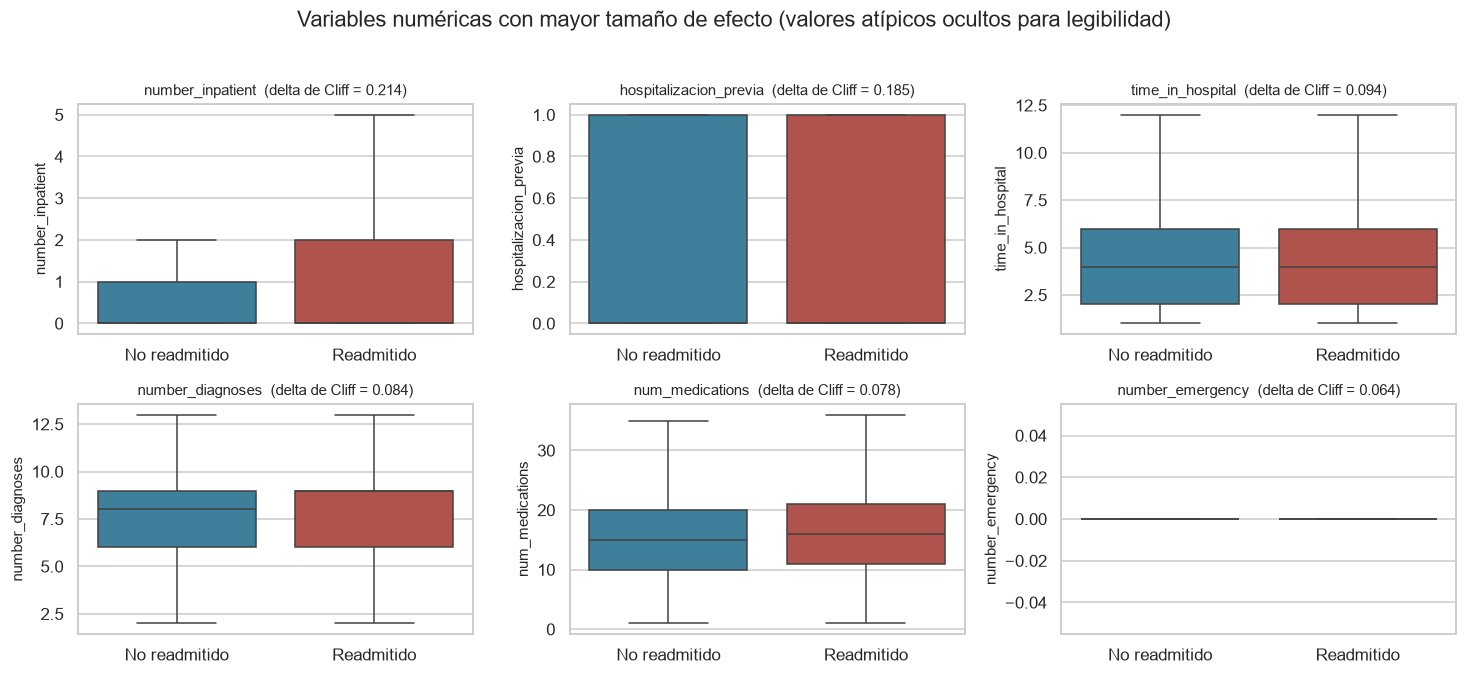

In [4]:
principales = asociacion_num.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(13.5, 6))
for ax, columna in zip(axes.flat, principales):
    sns.boxplot(data=train, x=OBJETIVO, y=columna, hue=OBJETIVO,
                palette=COLORES, legend=False, showfliers=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No readmitido", "Readmitido"])
    ax.set_xlabel("")
    delta = asociacion_num.loc[columna, "delta de Cliff"]
    ax.set_title(f"{columna}  (delta de Cliff = {delta:.3f})", fontsize=10)
fig.suptitle("Variables numéricas con mayor tamaño de efecto "
             "(valores atípicos ocultos para legibilidad)", y=1.02)
plt.tight_layout()
plt.show()

El resultado es el hallazgo central del análisis y condiciona las expectativas de todo el proyecto: **{glue:text}`c4_num_signif` de los {glue:text}`c4_num_total` contrastes numéricos son significativos tras la corrección de Holm y {glue:text}`c4_num_pequeno` alcanzan siquiera un efecto pequeño**.

El predictor numérico más asociado es {glue:text}`c4_mejor_num`, con una delta de Cliff de {glue:text}`c4_mejor_delta`, equivalente a un **AUC univariado de {glue:text}`c4_mejor_auc`**. Esa cifra es la referencia que conviene retener: cualquier modelo de los capítulos 7 y 8 que no la supere con holgura no está aportando nada que no estuviera ya en una sola columna.

Conviene notar que el orden cambia según la medida. La delta de Cliff es sensible al desplazamiento de toda la distribución, mientras que la correlación biserial se ve más influida por los valores extremos de las variables de conteo, de modo que las variables de utilización previa suben posiciones bajo la segunda. Ninguna de las dos lecturas es la correcta en abstracto: son preguntas distintas.

Las medianas difieren a lo sumo en un punto en las variables de proceso y son idénticas en las tres variables de utilización previa, donde la diferencia aparece únicamente en las medias: en `number_inpatient`, la media de los readmitidos más que duplica la de los no readmitidos mientras ambas medianas valen cero. Eso indica que en las variables con exceso de ceros **la señal está en las colas, no en un desplazamiento del centro de la distribución**: los readmitidos no son pacientes con "algo más" de historial, sino que entre ellos hay una fracción mayor de pacientes con historial muy alto.

Esto no es un defecto del análisis, sino una propiedad del problema. La readmisión hospitalaria es multicausal y depende en buena medida de factores que los datos administrativos no registran: adherencia al tratamiento, red de apoyo familiar, acceso efectivo al seguimiento ambulatorio, condiciones socioeconómicas y de vivienda.

La consecuencia práctica es que conviene **anticipar un desempeño moderado** y dejarlo consignado antes de presentar resultados. Si algún modelo logra capacidad discriminante, provendrá de combinaciones e interacciones entre variables más que de predictores individuales. Esa hipótesis no se deja en el aire: la sección 4.6 la contrasta explícitamente.

## 4.2. Forma de la relación: ¿es lineal en el logit?

Los contrastes anteriores dicen si una variable se asocia con el desenlace, pero no **cómo**. La distinción no es académica: la regresión logística supone que el logaritmo de la razón de momios es lineal en cada predictor, mientras que los árboles y los ensambles no suponen nada. Si la relación es monótona y aproximadamente lineal en esa escala, los modelos lineales parten sin desventaja; si no lo es, pierden señal que los ensambles sí pueden capturar.

Se examina agrupando cada predictor en tramos de igual tamaño, calculando la tasa de readmisión observada con intervalo de Wilson y representándola en la escala del logit.

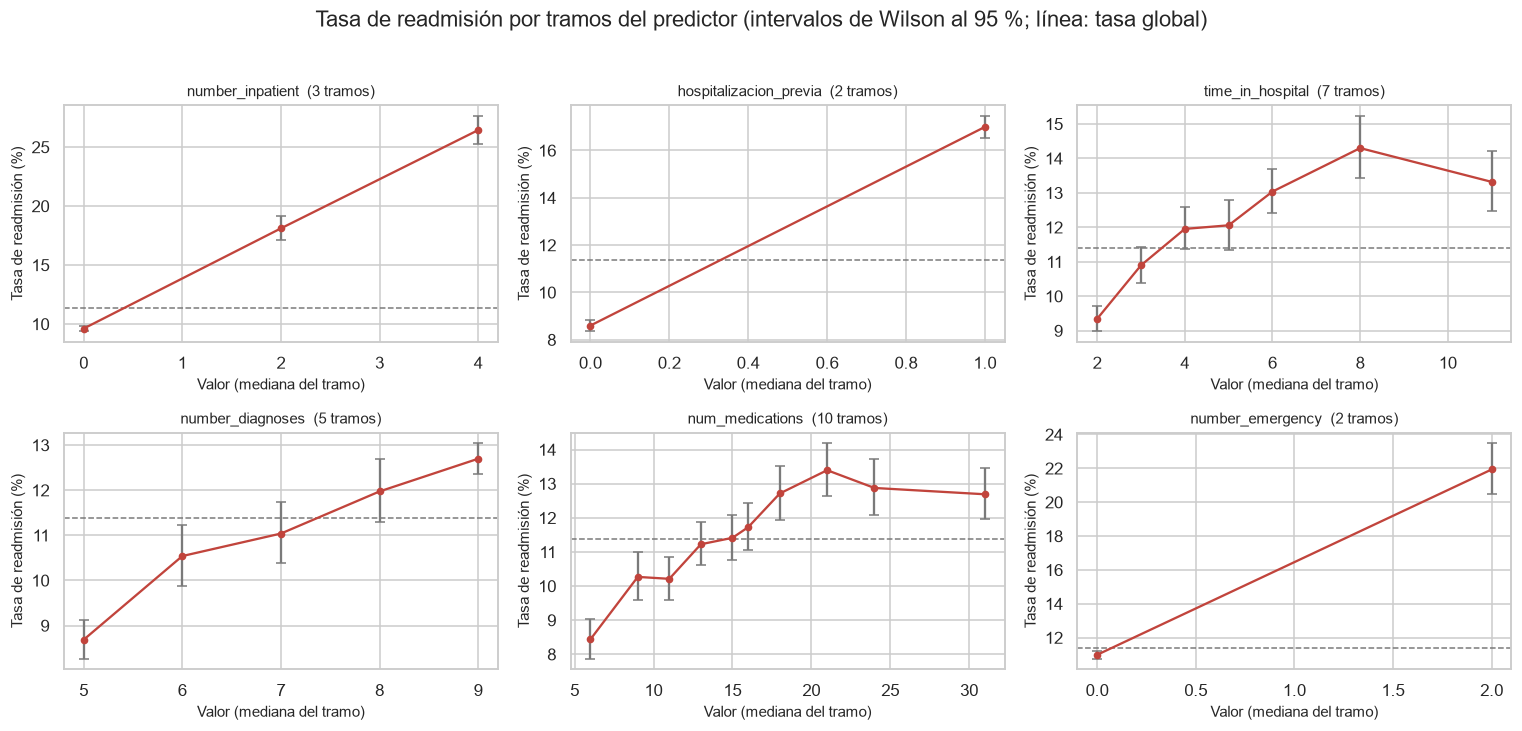

### Forma de la relación de cada predictor con el desenlace

In [5]:
def perfil_por_tramos(columna, n_tramos=10, minimo=200):
    """Tasa de readmisión por tramos de igual tamaño de un predictor.

    Los tramos se construyen por cuantiles, pero las variables con exceso de
    ceros no admiten diez cortes distintos: los duplicados se descartan y el
    número efectivo de tramos puede ser menor. Cuando el predictor tiene
    pocos valores distintos se usan directamente esos valores, que informan
    más que cualquier agrupación por cuantiles.

    Returns
    -------
    pandas.DataFrame
        Un renglón por tramo, con el centro del tramo, la tasa observada,
        el intervalo de Wilson al 95 % y el logit de la tasa.
    """
    if train[columna].nunique() <= n_tramos:
        tramos = train[columna]
    else:
        tramos = pd.qcut(train[columna], q=n_tramos, duplicates="drop")
    agrupado = train.groupby(tramos, observed=True).agg(
        n=(OBJETIVO, "size"), positivos=(OBJETIVO, "sum"),
        centro=(columna, "median"))
    agrupado = agrupado[agrupado["n"] >= minimo]
    limites = [intervalo_wilson(f["positivos"], f["n"])
               for _, f in agrupado.iterrows()]
    agrupado["tasa"] = agrupado["positivos"] / agrupado["n"]
    agrupado["inferior"] = [l[0] for l in limites]
    agrupado["superior"] = [l[1] for l in limites]
    agrupado["logit"] = np.log(agrupado["tasa"] / (1 - agrupado["tasa"]))
    return agrupado.reset_index(drop=True)


fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))
filas = []
for ax, columna in zip(axes.flat, principales):
    perfil = perfil_por_tramos(columna)
    ax.errorbar(perfil["centro"], 100 * perfil["tasa"],
                yerr=[100 * (perfil["tasa"] - perfil["inferior"]),
                      100 * (perfil["superior"] - perfil["tasa"])],
                fmt="o-", color=PALETA[1], ecolor=GRIS, capsize=3, ms=4)
    ax.axhline(tasa_global, ls="--", color=GRIS, lw=1)
    ax.set_title(f"{columna}  ({len(perfil)} tramos)", fontsize=10)
    ax.set_xlabel("Valor (mediana del tramo)")
    ax.set_ylabel("Tasa de readmisión (%)")
    if len(perfil) < 3:
        # Un predictor con dos niveles no tiene forma que examinar: cualquier
        # relación entre dos puntos es trivialmente monótona y lineal.
        filas.append({"variable": columna, "tramos": len(perfil),
                      "monotonía (Spearman)": np.nan,
                      "linealidad en el logit (Pearson)": np.nan,
                      "forma": "Sin tramos suficientes"})
        continue
    # Spearman mide si la relación es monótona; Pearson, si además es lineal
    # en la escala del logit, que es la que supone la regresión logística.
    # La diferencia entre ambos coeficientes es la curvatura.
    monotonia = stats.spearmanr(perfil["centro"], perfil["logit"]).statistic
    linealidad = stats.pearsonr(perfil["centro"], perfil["logit"]).statistic
    filas.append({"variable": columna, "tramos": len(perfil),
                  "monotonía (Spearman)": monotonia,
                  "linealidad en el logit (Pearson)": linealidad,
                  "forma": ("No monótona" if abs(monotonia) <= 0.8
                            else "Monótona y lineal en el logit"
                            if abs(linealidad) > 0.95
                            else "Monótona con curvatura")})
fig.suptitle("Tasa de readmisión por tramos del predictor "
             "(intervalos de Wilson al 95 %; línea: tasa global)", y=1.02)
plt.tight_layout()
plt.show()

forma = pd.DataFrame(filas).set_index("variable").round(3)
examinadas = forma["forma"] != "Sin tramos suficientes"

anotar("c4_examinadas", int(examinadas.sum()))
anotar("c4_lineales", int((forma["forma"] == "Monótona y lineal en el logit").sum()))
anotar("c4_curvatura", int((forma["forma"] == "Monótona con curvatura").sum()))
anotar("c4_no_monotonas", int((forma["forma"] == "No monótona").sum()))
tabla(forma, filas=10,
      titulo="Forma de la relación de cada predictor con el desenlace")

El panel aporta tres conclusiones que ninguna de las tablas anteriores podía dar.

La primera es que **las relaciones son monótonas**: de las {glue:text}`c4_examinadas` variables con tramos suficientes para examinar la forma, {glue:text}`c4_no_monotonas` resultan no monótonas. No hay relaciones en forma de U que obliguen a transformar nada, lo que descarta un problema que sí aparece con frecuencia en datos clínicos.

La segunda matiza a la primera: {glue:text}`c4_lineales` de ellas son además aproximadamente lineales en la escala del logit y {glue:text}`c4_curvatura` presentan curvatura apreciable. La distinción importa porque es la escala en la que trabaja la regresión logística. Donde hay curvatura, el salto grande se produce entre el valor cero y el uno y no a lo largo del recorrido, que es exactamente el patrón de las variables de utilización previa. Esa forma explica por qué el capítulo 2 derivó `hospitalizacion_previa`: sin esa variable, un modelo lineal solo puede aproximar el salto con una pendiente que reparte mal el efecto a lo largo de toda la cola.

La tercera es que los intervalos de Wilson de los tramos centrales se solapan entre sí y con la tasa global en casi todas las variables. Solo los tramos extremos se separan con claridad. Esto refuerza la lectura de la sección anterior: la señal existe, pero vive en los extremos de la distribución y afecta a una fracción pequeña de los encuentros.

La consecuencia para el modelado es concreta y contrastable: **los modelos que particionan el espacio (árboles, bosques, potenciación de gradiente) deberían aprovechar la curvatura sin necesidad de declararla**, mientras que los lineales dependen de que las derivaciones del capítulo 2 se la hayan dado ya masticada. Es una predicción que los capítulos 7 y 8 pueden confirmar o refutar.

## 4.3. Variables categóricas frente al desenlace

Se contrasta la independencia con la prueba **chi-cuadrado** y se mide la intensidad con la **V de Cramér** corregida por sesgo, comparable entre variables con distinto número de categorías.

### 4.3.1. Verificación de supuestos

La aproximación chi-cuadrado exige frecuencias esperadas suficientes; la regla habitual pide que ninguna celda baje de 1 y que no más del 20 % quede por debajo de 5. Se verifica explícitamente en cada tabla, porque en este conjunto el supuesto **no se cumplía antes de agrupar las categorías poco frecuentes** en el capítulo 2.

In [6]:
filas = []
for columna in CATEGORICAS:
    contingencia = pd.crosstab(train[columna], train[OBJETIVO])
    chi2, p, gl, esperadas = stats.chi2_contingency(contingencia)
    filas.append({
        "variable": columna,
        "categorías": contingencia.shape[0],
        "mín. frecuencia esperada": esperadas.min(),
        "% celdas con esperada < 5": 100 * (esperadas < 5).mean(),
        "chi²": chi2,
        "gl": gl,
        "p": p,
        "V de Cramér": v_cramer(contingencia),
    })

asociacion_cat = pd.DataFrame(filas).set_index("variable")
asociacion_cat["p (Holm)"] = correccion_holm(asociacion_cat["p"])
asociacion_cat["supuesto chi² cumplido"] = np.where(
    (asociacion_cat["mín. frecuencia esperada"] >= 1)
    & (asociacion_cat["% celdas con esperada < 5"] <= 20), "Sí", "No")
asociacion_cat["significativa (Holm)"] = np.where(
    asociacion_cat["p (Holm)"] < 0.05, "Sí", "No")
asociacion_cat = asociacion_cat.sort_values("V de Cramér", ascending=False)

perdidas = asociacion_cat[(asociacion_cat["p"] < 0.05)
                          & (asociacion_cat["p (Holm)"] >= 0.05)]
incumplen = asociacion_cat[asociacion_cat["supuesto chi² cumplido"] == "No"]

anotar("c4_mejor_cat", asociacion_cat.index[0])
anotar("c4_lista_incumplen", ", ".join(incumplen.index)
       if len(incumplen) else "ninguna")
anotar("c4_incumplen_signif", int(
    (incumplen["significativa (Holm)"] == "Sí").sum()))
anotar("c4_mejor_v", f"{asociacion_cat['V de Cramér'].iloc[0]:.3f}")
anotar("c4_cat_signif", int(
    (asociacion_cat["significativa (Holm)"] == "Sí").sum()))
anotar("c4_cat_total", len(asociacion_cat))
anotar("c4_supuesto", int(
    (asociacion_cat["supuesto chi² cumplido"] == "No").sum()))
anotar("c4_perdidas", int(len(perdidas)))
anotar("c4_lista_perdidas", ", ".join(perdidas.index))

guardar_resultado(asociacion_cat, "asociacion_categoricas")
tabla(asociacion_cat.round(4), filas=30,
      titulo="Asociación de las variables categóricas con la readmisión")

### Asociación de las variables categóricas con la readmisión

Tras el agrupamiento del capítulo 2, **{glue:text}`c4_supuesto` de las {glue:text}`c4_cat_total` variables siguen incumpliendo el supuesto de frecuencias esperadas**: {glue:text}`c4_lista_incumplen`. Son los fármacos que quedaron justo por encima del umbral de variación mínima, con niveles que reúnen apenas unas decenas de encuentros. Su valor p **no es interpretable** y no debe usarse para afirmar ni negar asociación. La comprobación tranquilizadora es que {glue:text}`c4_incumplen_signif` de ellas resulta significativa tras Holm, de modo que ninguna conclusión del capítulo depende de una prueba mal condicionada. Para el resto de variables el supuesto se cumple y los valores p son interpretables.

Merece registrarse que el agrupamiento tuvo un efecto secundario incómodo pero correcto: en las variables con muchas categorías raras la V de Cramér baja al agrupar, porque parte de la asociación aparente provenía de celdas con muy pocos casos y estimaciones inestables. El valor agrupado es el estimador honesto, aunque resulte menos favorable.

La corrección por comparaciones múltiples también cambia conclusiones: **{glue:text}`c4_cat_signif` de las {glue:text}`c4_cat_total` variables categóricas mantienen la significancia tras Holm**, encabezadas por {glue:text}`c4_mejor_cat` (V de Cramér {glue:text}`c4_mejor_v`). Hay {glue:text}`c4_perdidas` variables que eran significativas sin corregir y dejan de serlo al aplicarla: {glue:text}`c4_lista_perdidas`. Sus valores p sin ajustar quedaban justo en el rango donde la corrección marca la diferencia; sin ella se habrían reportado como hallazgos.

### 4.3.2. Tasa de readmisión por categoría

La V de Cramér mide intensidad global, pero no dice qué categorías concentran el riesgo. Se examina la tasa de readmisión por nivel, restringida a categorías con al menos 200 encuentros para que las estimaciones sean estables, y acompañada de un intervalo de confianza binomial.

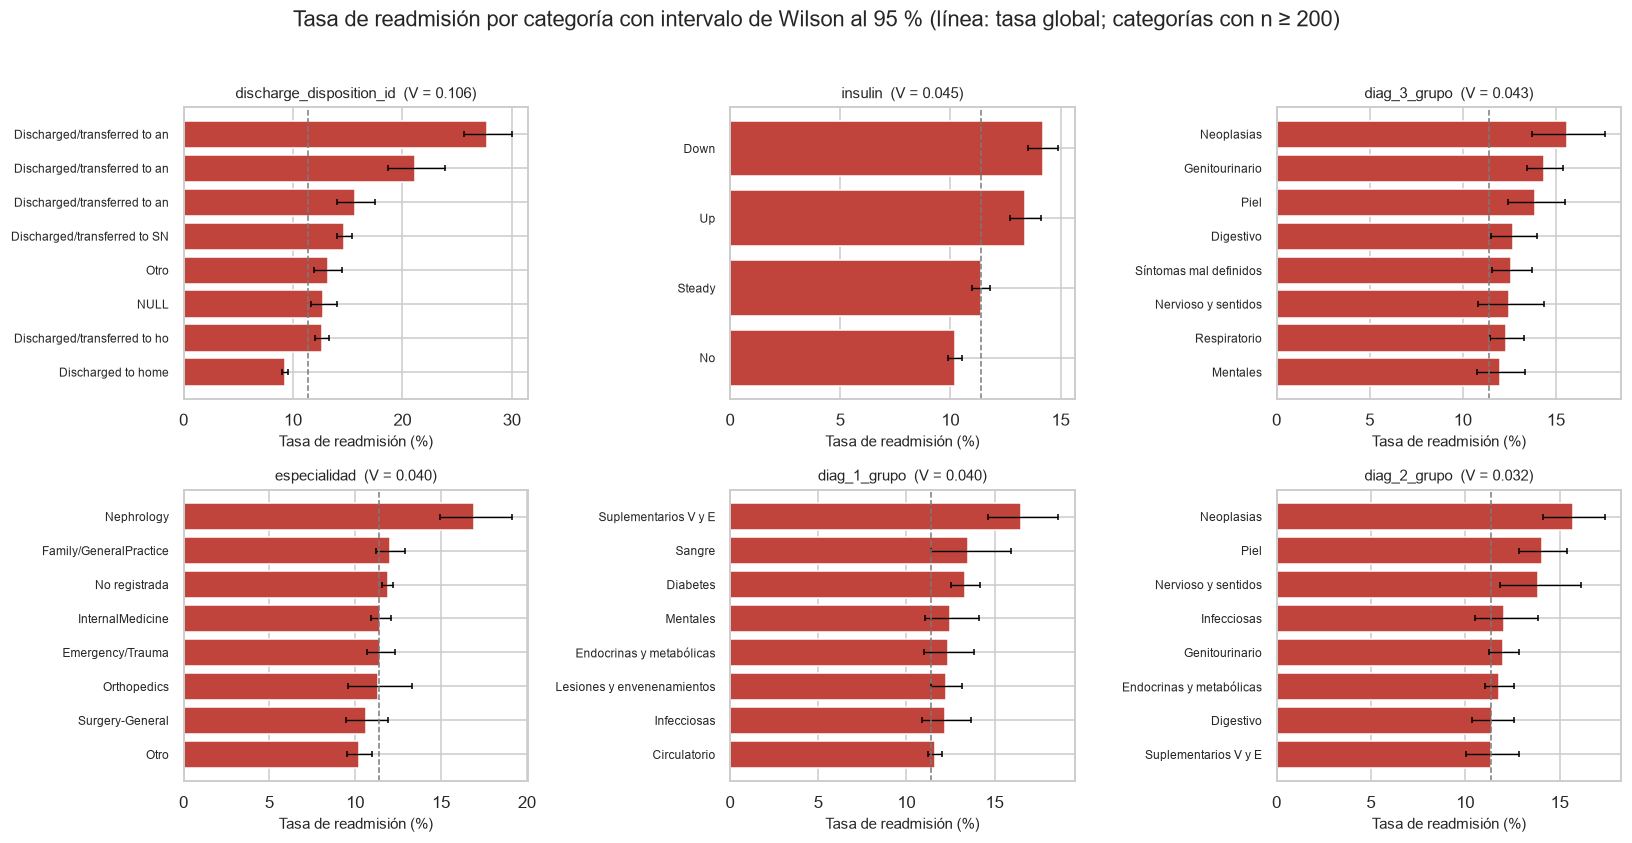

In [7]:
def tasa_por_categoria(datos, columna, minimo=200):
    """Tasa de readmisión por categoría con intervalo de Wilson al 95 %."""
    agrupado = datos.groupby(columna, observed=True)[OBJETIVO].agg(
        ["size", "sum", "mean"])
    agrupado = agrupado[agrupado["size"] >= minimo]
    limites = [intervalo_wilson(fila["sum"], fila["size"])
               for _, fila in agrupado.iterrows()]
    agrupado["inferior"] = [100 * l[0] for l in limites]
    agrupado["superior"] = [100 * l[1] for l in limites]
    agrupado["tasa (%)"] = 100 * agrupado["mean"]
    return agrupado.sort_values("tasa (%)", ascending=False)


DESTACADAS = asociacion_cat.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, columna in zip(axes.flat, DESTACADAS):
    resumen = tasa_por_categoria(train, columna).head(8)
    posiciones = np.arange(len(resumen))[::-1]
    ax.barh(posiciones, resumen["tasa (%)"], color=PALETA[1])
    ax.errorbar(resumen["tasa (%)"], posiciones,
                xerr=[resumen["tasa (%)"] - resumen["inferior"],
                      resumen["superior"] - resumen["tasa (%)"]],
                fmt="none", ecolor="black", elinewidth=0.9, capsize=2)
    ax.set_yticks(posiciones)
    ax.set_yticklabels([str(i)[:28] for i in resumen.index], fontsize=8)
    ax.axvline(tasa_global, ls="--", color=GRIS, lw=1)
    ax.set_xlabel("Tasa de readmisión (%)")
    ax.set_title(
        f"{columna}  (V = {asociacion_cat.loc[columna, 'V de Cramér']:.3f})",
        fontsize=10)
fig.suptitle("Tasa de readmisión por categoría con intervalo de Wilson al 95 % "
             "(línea: tasa global; categorías con n ≥ 200)", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
detalle_alta = tasa_por_categoria(train, "discharge_disposition_id")[
    ["size", "tasa (%)", "inferior", "superior"]].round(2)

anotar("c4_alta_max", f"{detalle_alta['tasa (%)'].max():.1f}")
anotar("c4_alta_min", f"{detalle_alta['tasa (%)'].min():.1f}")
tabla(detalle_alta, filas=15,
      titulo="Readmisión según el destino al alta")

### Readmisión según el destino al alta

El destino al alta es la variable categórica más asociada al desenlace, con tasas que van del {glue:text}`c4_alta_min` % al {glue:text}`c4_alta_max` % según la categoría. Los pacientes trasladados a otras instituciones de cuidado (rehabilitación, centros de larga estancia, atención domiciliaria) presentan tasas que superan claramente la media, con intervalos de confianza que no la incluyen, mientras que el alta a domicilio queda por debajo. El patrón es clínicamente coherente: el destino al alta resume la fragilidad del paciente y la intensidad del cuidado que requiere.

Es importante señalar que esta variable se determina **en el momento del alta**, por lo que su uso como predictor es legítimo y no constituye fuga de información. El capítulo 5 revisa este punto para todos los bloques.

## 4.4. Bloque clínico: control glucémico y tratamiento

Las dos pruebas de laboratorio y el manejo farmacológico merecen un examen específico: son el núcleo clínico del conjunto de datos y motivaron su publicación original, que se centró justamente en el efecto de medir la hemoglobina glicosilada sobre la readmisión.

In [9]:
CLINICAS = ["A1Cresult", "max_glu_serum", "insulin", "change", "diabetesMed"]

filas = []
for columna in CLINICAS:
    for categoria, grupo in train.groupby(columna, observed=True):
        inferior, superior = intervalo_wilson(grupo[OBJETIVO].sum(), len(grupo))
        filas.append({
            "variable": columna,
            "categoría": categoria,
            "encuentros": len(grupo),
            "tasa (%)": 100 * grupo[OBJETIVO].mean(),
            "IC 95 % inferior": 100 * inferior,
            "IC 95 % superior": 100 * superior,
        })

resumen_clinico = pd.DataFrame(filas).round(2)

a1c = resumen_clinico[resumen_clinico["variable"] == "A1Cresult"].set_index(
    "categoría")
medida = a1c.drop(index="No medida")
sin_medir = a1c.loc["No medida"]

anotar("c4_a1c_sin_medir", f"{sin_medir['tasa (%)']:.2f}")
anotar("c4_a1c_medida",
       f"{medida['tasa (%)'].min():.2f} y {medida['tasa (%)'].max():.2f}")
anotar("c4_a1c_brecha",
       f"{sin_medir['tasa (%)'] - medida['tasa (%)'].max():.2f}")
anotar("c4_a1c_v", f"{asociacion_cat.loc['A1Cresult', 'V de Cramér']:.3f}")
anotar("c4_a1c_sep",
       "no se solapan" if medida["IC 95 % superior"].max()
       < sin_medir["IC 95 % inferior"] else "se solapan")
tabla(resumen_clinico, filas=25,
      titulo="Control glucémico y tratamiento farmacológico", indice=False)

### Control glucémico y tratamiento farmacológico

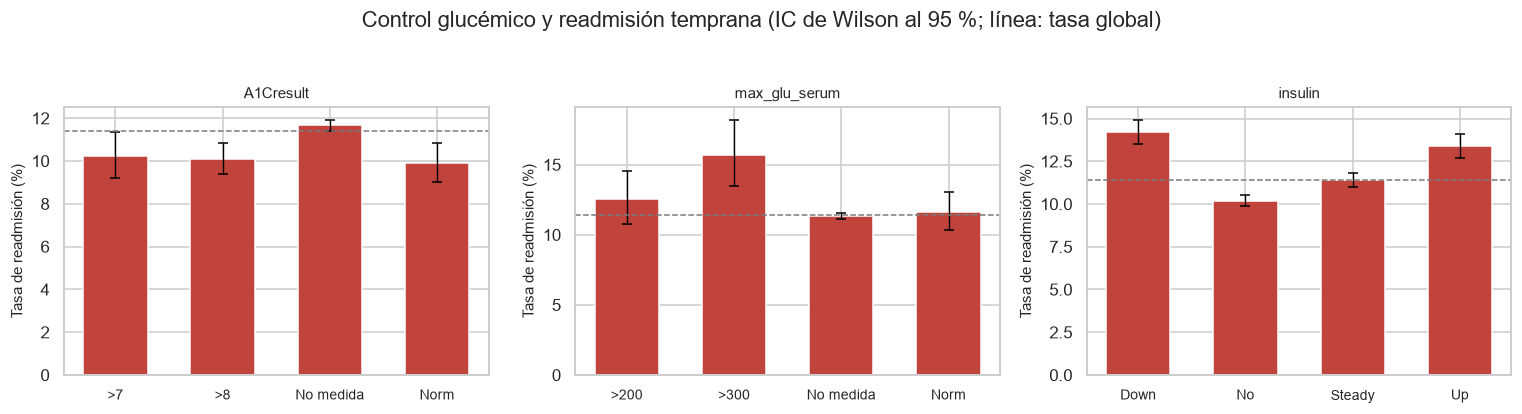

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, columna in zip(axes, ["A1Cresult", "max_glu_serum", "insulin"]):
    sub = resumen_clinico[resumen_clinico["variable"] == columna]
    posiciones = np.arange(len(sub))
    ax.bar(posiciones, sub["tasa (%)"], color=PALETA[1], width=0.6)
    ax.errorbar(posiciones, sub["tasa (%)"],
                yerr=[sub["tasa (%)"] - sub["IC 95 % inferior"],
                      sub["IC 95 % superior"] - sub["tasa (%)"]],
                fmt="none", ecolor="black", elinewidth=0.9, capsize=3)
    ax.axhline(tasa_global, ls="--", color=GRIS, lw=1)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(sub["categoría"], fontsize=9)
    ax.set_ylabel("Tasa de readmisión (%)")
    ax.set_title(columna, fontsize=10)
fig.suptitle("Control glucémico y readmisión temprana "
             "(IC de Wilson al 95 %; línea: tasa global)", y=1.04)
plt.tight_layout()
plt.show()

El resultado reproduce el hallazgo que motivó la publicación original del conjunto de datos, y merece discusión explícita en el artículo: **lo que se asocia con la readmisión no es el valor de la hemoglobina glicosilada, sino el hecho de haberla medido**.

Los encuentros en los que no se midió tienen una tasa del {glue:text}`c4_a1c_sin_medir` %, frente a un rango del {glue:text}`c4_a1c_medida` % entre los tres niveles medidos —normal, superior a 7 y superior a 8—, que apenas se distinguen entre sí. La brecha es de {glue:text}`c4_a1c_brecha` puntos porcentuales y los intervalos de Wilson de ambos bloques {glue:text}`c4_a1c_sep`. Dicho de otro modo: una vez que la prueba se realiza, su resultado no cambia el pronóstico de readmisión a 30 días.

Ahora bien, la magnitud es pequeña: la V de Cramér de `A1Cresult` es {glue:text}`c4_a1c_v`. Este es el ejemplo más claro del capítulo de por qué la significancia no basta. Con casi ochenta mil encuentros la prueba chi-cuadrado rechaza la independencia sin dificultad y sobrevive la corrección de Holm, pero una diferencia de poco más de un punto porcentual no cambia por sí sola ninguna decisión clínica. Lo mismo ocurre con la insulina, donde subir o bajar la dosis se asocia con tasas superiores a mantenerla o no usarla: el patrón es coherente y significativo, y su tamaño sigue siendo de dos a cuatro puntos.

Hay dos lecturas posibles de la brecha entre medir y no medir, no excluyentes:

1. **Medir refleja un proceso de atención más completo.** Ordenar la prueba indica que el equipo revisó el control metabólico del paciente, lo que suele ir acompañado de una mejor planificación del alta y del seguimiento. En esa lectura la variable no describe al paciente sino al proceso, y el efecto sería causal a través del cuidado recibido.
2. **Confusión por indicación.** La decisión de medir no es aleatoria: depende del estado del paciente y del motivo del ingreso. Los pacientes a quienes se mide son sistemáticamente distintos de aquellos a quienes no, y esa diferencia puede explicar la brecha sin que medir tenga efecto propio alguno.

Con un diseño observacional no es posible separar ambas, y esa imposibilidad debe declararse como limitación en lugar de resolverse con una afirmación causal. Lo que sí queda establecido, y es lo relevante para el proyecto, es que **la categoría "no medida" debe conservarse como nivel propio y no imputarse**: es precisamente la que más información aporta del bloque, tal como decidió el capítulo 2.

## 4.5. Un ranking único de todos los predictores

Las secciones anteriores usan estadísticos distintos para variables numéricas y categóricas, lo que impide ordenarlas en una sola lista. Esta sección resuelve ese problema con la **información mutua**, que se define igual para cualquier tipo de variable y mide cuánta incertidumbre sobre el desenlace elimina conocer el predictor, sin suponer linealidad ni monotonía.

La información mutua estimada por conteo directo tiene un sesgo positivo conocido que crece con el número de categorías, de modo que una variable con muchos niveles parece informativa aunque no lo sea. Para neutralizarlo se calcula una **referencia por permutación**: se recalcula la misma cantidad con las etiquetas mezcladas al azar y se resta. Lo que queda es la información atribuible a la asociación y no al número de niveles.

Se acompaña del **AUC univariado** de cada predictor. Para las categóricas se obtiene codificando cada nivel por su tasa de readmisión, pero estimada **fuera de muestra** mediante validación cruzada agrupada por paciente: calcular la tasa con los mismos datos con los que se evalúa produciría un AUC inflado, exactamente la fuga que el proyecto quiere evitar.

In [11]:
def codificar(serie, tramos=10):
    """Convierte cualquier predictor en códigos enteros para estimar entropías.

    Las categóricas usan sus propios niveles; las numéricas se discretizan en
    tramos de igual frecuencia, que es el criterio que menos supuestos impone
    sobre la forma de la distribución.
    """
    if serie.dtype.kind in "biufc" and serie.nunique() > tramos:
        return pd.qcut(serie, q=tramos, duplicates="drop").cat.codes.to_numpy()
    return serie.astype("category").cat.codes.to_numpy()


def informacion_mutua(codigos, etiquetas):
    """Información mutua por conteo directo, en nats.

    Parameters
    ----------
    codigos : numpy.ndarray
        Predictor discretizado, con códigos enteros consecutivos.
    etiquetas : numpy.ndarray
        Variable objetivo binaria.

    Returns
    -------
    float
        Información mutua entre ambas variables.
    """
    k = codigos.max() + 1
    conjunta = np.bincount(codigos * 2 + etiquetas, minlength=2 * k)
    conjunta = conjunta.reshape(k, 2) / len(codigos)
    marginal_x = conjunta.sum(axis=1, keepdims=True)
    marginal_y = conjunta.sum(axis=0, keepdims=True)
    esperada = marginal_x * marginal_y
    positivas = conjunta > 0
    return float(np.sum(conjunta[positivas]
                        * np.log(conjunta[positivas] / esperada[positivas])))


# Los pliegues se calculan una sola vez y se reutilizan para todas las
# variables: construirlos es la operación cara con 56 mil grupos.
PLIEGUES = list(StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
).split(train, objetivo, grupos))


def auc_fuera_de_muestra(columna):
    """AUC univariado de una categórica con codificación fuera de muestra.

    Cada nivel se sustituye por la tasa de readmisión estimada en los pliegues
    de entrenamiento, nunca en el pliegue donde se evalúa. Los pliegues se
    agrupan por paciente para que la codificación no se beneficie de haber
    visto otros encuentros del mismo paciente. Sin esta precaución el AUC
    saldría inflado, que es justamente la fuga que el proyecto evita.
    """
    valores = train[columna]
    puntuacion = np.empty(len(train))
    for entreno, evaluacion in PLIEGUES:
        tasas = objetivo[entreno].astype(float)
        tasas = pd.Series(tasas, index=valores.iloc[entreno]).groupby(
            level=0, observed=True).mean()
        puntuacion[evaluacion] = (valores.iloc[evaluacion]
                                  .map(tasas)
                                  .fillna(objetivo[entreno].mean())
                                  .to_numpy())
    return roc_auc_score(objetivo, puntuacion)


PERMUTACIONES = 20
generador = np.random.default_rng(RANDOM_STATE)
entropia_objetivo = informacion_mutua(objetivo, objetivo)

filas = []
for columna in PREDICTORES:
    codigos = codificar(train[columna])
    observada = informacion_mutua(codigos, objetivo)
    nula = np.mean([informacion_mutua(codigos, generador.permutation(objetivo))
                    for _ in range(PERMUTACIONES)])
    if columna in NUMERICAS + BINARIAS:
        auc = asociacion_num.loc[columna, "AUC univariado"]
    else:
        auc = auc_fuera_de_muestra(columna)
    filas.append({
        "variable": columna,
        "tipo": "numérica" if columna in NUMERICAS
                else "binaria" if columna in BINARIAS else "categórica",
        "niveles": codigos.max() + 1,
        "información mutua": observada,
        "referencia por permutación": nula,
        "información mutua neta": observada - nula,
        "% de la entropía del desenlace":
            100 * (observada - nula) / entropia_objetivo,
        "AUC univariado": auc,
        "|AUC - 0.5|": abs(auc - 0.5),
    })

ranking = (pd.DataFrame(filas).set_index("variable")
           .sort_values("información mutua neta", ascending=False))

guardar_resultado(ranking, "ranking_predictores")
anotar("c4_top_mi", ranking.index[0])
anotar("c4_top_mi_pct",
       f"{ranking['% de la entropía del desenlace'].iloc[0]:.2f}")
anotar("c4_top_auc", f"{ranking['AUC univariado'].abs().max():.3f}")
anotar("c4_mi_negativa", int((ranking["información mutua neta"] <= 0).sum()))
tabla(ranking.round(5), filas=40,
      titulo="Ranking único de predictores por información mutua neta")

### Ranking único de predictores por información mutua neta

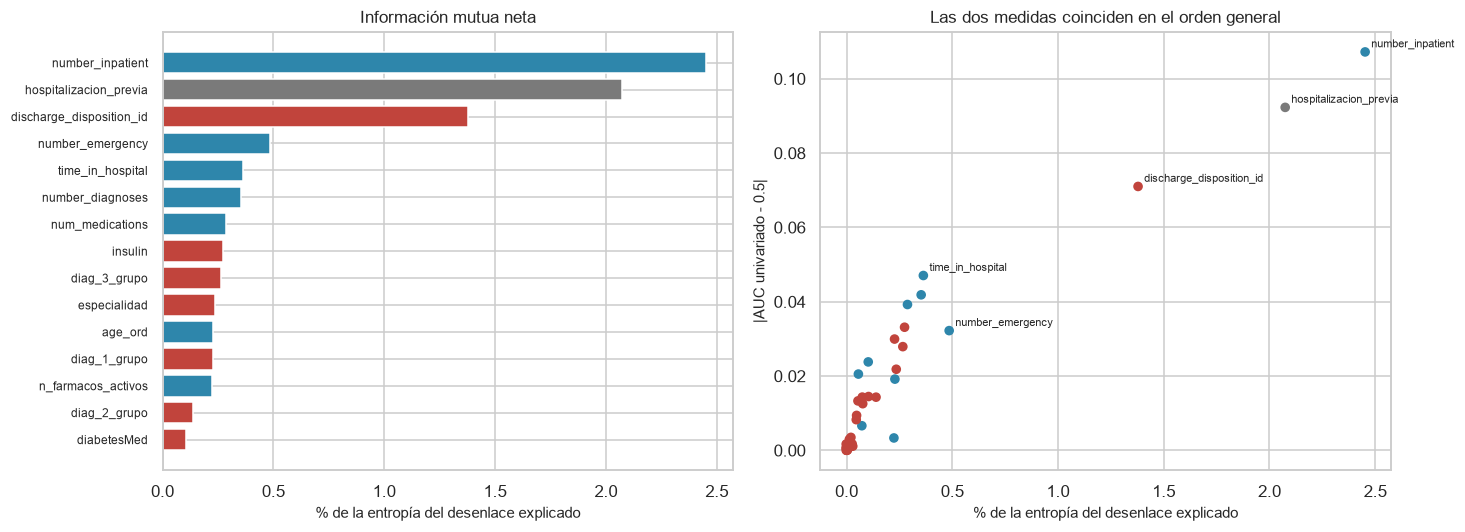

In [12]:
mejores = ranking.head(15).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
colores_tipo = {"numérica": PALETA[0], "binaria": GRIS,
                "categórica": PALETA[1]}
axes[0].barh(mejores.index, mejores["% de la entropía del desenlace"],
             color=[colores_tipo[t] for t in mejores["tipo"]])
axes[0].set_xlabel("% de la entropía del desenlace explicado")
axes[0].set_title("Información mutua neta")
axes[0].tick_params(axis="y", labelsize=8)

axes[1].scatter(ranking["% de la entropía del desenlace"],
                ranking["|AUC - 0.5|"],
                c=[colores_tipo[t] for t in ranking["tipo"]], s=28)
for variable in ranking.head(5).index:
    axes[1].annotate(variable,
                     (ranking.loc[variable, "% de la entropía del desenlace"],
                      ranking.loc[variable, "|AUC - 0.5|"]),
                     fontsize=7, xytext=(4, 3), textcoords="offset points")
axes[1].set_xlabel("% de la entropía del desenlace explicado")
axes[1].set_ylabel("|AUC univariado - 0.5|")
axes[1].set_title("Las dos medidas coinciden en el orden general")
plt.tight_layout()
plt.show()

El ranking unificado confirma y precisa lo anterior. El predictor más informativo es {glue:text}`c4_top_mi`, y aun así explica solo el **{glue:text}`c4_top_mi_pct` % de la entropía del desenlace**. El mejor AUC univariado de todo el conjunto es {glue:text}`c4_top_auc`. Hay {glue:text}`c4_mi_negativa` predictores cuya información mutua no supera su propia referencia por permutación: lo poco que aportaban era sesgo del estimador, no asociación.

El panel derecho muestra que ambas medidas ordenan las variables de forma parecida, lo cual es tranquilizador pero no trivial: la información mutua detecta relaciones no monótonas que el AUC no puede ver, así que una discrepancia grande habría señalado una variable con estructura en forma de U. No aparece ninguna.

La conclusión es inequívoca y hay que dejarla escrita antes de presentar cualquier resultado de modelado: **ningún predictor individual separa las clases**. Un modelo que alcance un AUC apreciablemente superior a {glue:text}`c4_top_auc` estará combinando información, no explotando una variable dominante.

## 4.6. ¿Está la señal en las interacciones?

La sección anterior deja una hipótesis sobre la mesa: si ningún predictor individual funciona pero los modelos alcanzan un desempeño razonable, la señal debe estar en las combinaciones. Conviene contrastarla aquí y no dejarla como conjetura, porque de ella depende la expectativa sobre qué familia de modelos debería ganar.

Conviene anticipar que el resultado de esta sección es **cuantitativamente modesto**, y eso es en sí un hallazgo: sirve para no prometer en el artículo una mejora que los modelos no van a entregar.

La herramienta es la **información de interacción**, la diferencia entre lo que un par de variables informa conjuntamente y lo que informan por separado:

`II(X₁, X₂; Y) = I(X₁, X₂; Y) − I(X₁; Y) − I(X₂; Y)`

Un valor positivo indica **sinergia**: el par dice más que la suma de sus partes, que es exactamente lo que un modelo capaz de representar interacciones puede aprovechar y uno aditivo no. Un valor negativo indica **redundancia**: las dos variables cuentan lo mismo. Cada término se corrige por su propia referencia de permutación, porque la variable conjunta tiene muchos más niveles y sufre más sesgo que las marginales.

In [13]:
CANDIDATAS = list(ranking.head(8).index)
PERMUTACIONES_PAR = 10

codigos_por_variable = {c: codificar(train[c], tramos=5) for c in CANDIDATAS}


def informacion_neta(codigos, repeticiones=PERMUTACIONES_PAR):
    """Información mutua con su sesgo de discretización ya descontado."""
    observada = informacion_mutua(codigos, objetivo)
    nula = np.mean([informacion_mutua(codigos, generador.permutation(objetivo))
                    for _ in range(repeticiones)])
    return observada - nula


individual = {c: informacion_neta(v) for c, v in codigos_por_variable.items()}

filas = []
for i, primera in enumerate(CANDIDATAS):
    for segunda in CANDIDATAS[i + 1:]:
        a, b = codigos_por_variable[primera], codigos_por_variable[segunda]
        conjunto = a * (b.max() + 1) + b
        # Se recodifica para que los niveles sean consecutivos y el conteo no
        # recorra celdas vacías.
        conjunto = pd.Series(conjunto).astype("category").cat.codes.to_numpy()
        conjunta = informacion_neta(conjunto)
        filas.append({
            "variable 1": primera,
            "variable 2": segunda,
            "I neta conjunta": conjunta,
            "suma de las individuales": individual[primera] + individual[segunda],
            "información de interacción":
                conjunta - individual[primera] - individual[segunda],
        })

interacciones = (pd.DataFrame(filas)
                 .sort_values("información de interacción", ascending=False)
                 .reset_index(drop=True))
interacciones["relación"] = np.where(
    interacciones["información de interacción"] > 0, "Sinergia", "Redundancia")

guardar_resultado(interacciones, "interaccion_pares")
anotar("c4_sinergias", int((interacciones["información de interacción"] > 0).sum()))
anotar("c4_pares", len(interacciones))
anotar("c4_par_top", f"{interacciones.loc[0, 'variable 1']} y "
                     f"{interacciones.loc[0, 'variable 2']}")
anotar("c4_ganancia_par", f"{100 * interacciones['información de interacción'].max() / entropia_objetivo:.3f}")
tabla(interacciones.round(5), filas=30,
      titulo="Información de interacción entre pares de los ocho predictores "
             "más informativos", indice=False)

### Información de interacción entre pares de los ocho predictores más informativos

C:\Users\joshu\AppData\Local\Temp\ipykernel_2288\2332573455.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


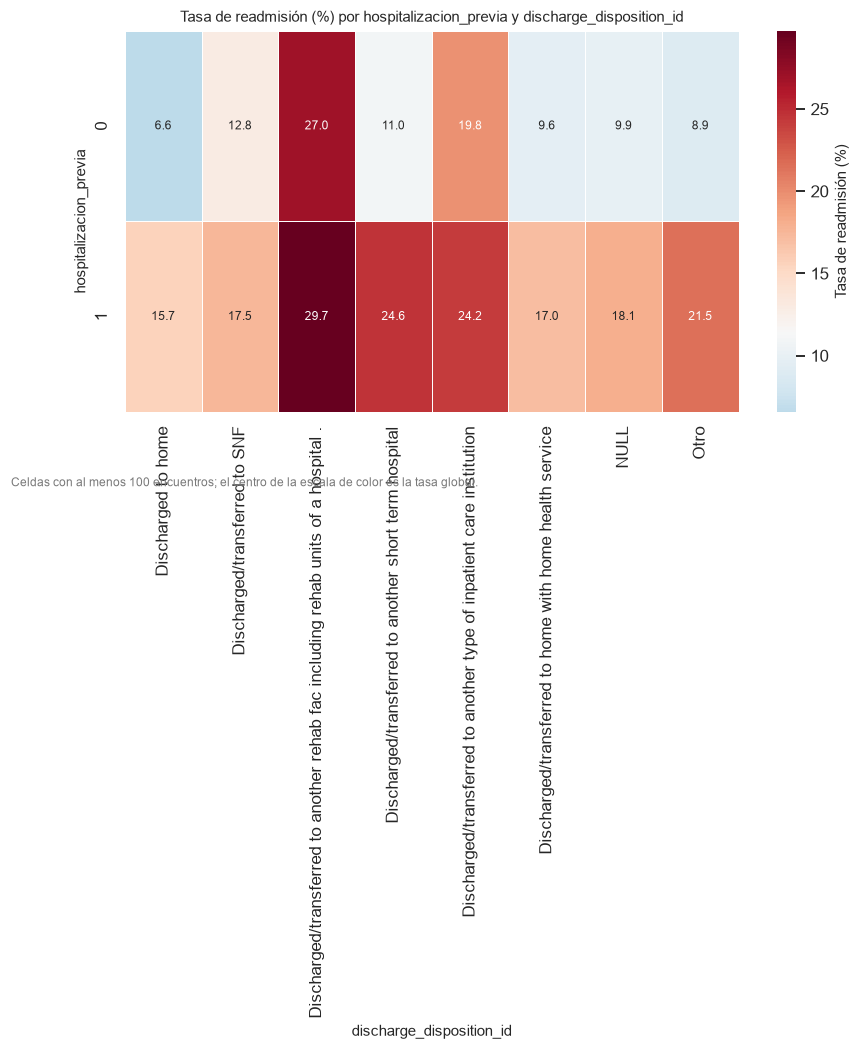

Amplitud de la tasa dentro de cada fila del mapa:
hospitalizacion_previa
0    20.45
1    14.09


In [14]:
# El par con mayor sinergia, visto como tabla de tasas: es la forma directa de
# comprobar si el efecto de una variable cambia según el nivel de la otra.
par = (interacciones.loc[0, "variable 1"], interacciones.loc[0, "variable 2"])
ejes = []
for columna in par:
    if columna in NUMERICAS and train[columna].nunique() > 5:
        ejes.append(pd.qcut(train[columna], q=4, duplicates="drop"))
    else:
        ejes.append(train[columna])

celdas = train.groupby([ejes[0], ejes[1]], observed=True)[OBJETIVO].agg(
    ["size", "mean"])
mapa = (100 * celdas["mean"]).unstack()
tamanos = celdas["size"].unstack()
mapa = mapa.where(tamanos >= 100)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(mapa, annot=True, fmt=".1f", cmap="RdBu_r", center=tasa_global,
            linewidths=0.4, cbar_kws={"label": "Tasa de readmisión (%)"},
            annot_kws={"size": 8}, ax=ax)
ax.set_title(f"Tasa de readmisión (%) por {par[0]} y {par[1]}", fontsize=10)
ax.set_xlabel(par[1])
ax.set_ylabel(par[0])
fig.text(0.01, -0.04, "Celdas con al menos 100 encuentros; el centro de la "
                      "escala de color es la tasa global.", fontsize=8,
         color=GRIS)
plt.tight_layout()
plt.show()

rango_filas = (mapa.max(axis=1) - mapa.min(axis=1)).round(2)
anotar("c4_rango_celdas", f"{mapa.min().min():.1f} y {mapa.max().max():.1f}")
print("Amplitud de la tasa dentro de cada fila del mapa:")
print(rango_filas.to_string())

De los {glue:text}`c4_pares` pares evaluados, {glue:text}`c4_sinergias` muestran sinergia y el resto son redundantes. La mayor sinergia corresponde a {glue:text}`c4_par_top`, y su ganancia sobre la suma de las partes equivale al {glue:text}`c4_ganancia_par` % de la entropía del desenlace. **Conviene no maquillar esa cifra: es pequeña**, del orden de la vigésima parte de lo que aporta el mejor predictor individual por sí solo.

El mapa de calor traduce el resultado a algo interpretable. La tasa de readmisión recorre el intervalo entre el {glue:text}`c4_rango_celdas` % según la celda, un rango bastante más amplio que el de cualquiera de las dos variables por separado, y el efecto del destino al alta cambia de magnitud según haya habido o no hospitalización previa. La interacción existe y es del signo esperado; lo que no es es grande.

El par más redundante del conjunto es igualmente instructivo: `number_inpatient` con `hospitalizacion_previa`, con la información de interacción más negativa de la tabla. No es un hallazgo sino una comprobación, porque la segunda es la binarización de la primera y por construcción cuentan lo mismo. Que el estimador lo detecte sin que se le diga confirma que la medida se comporta como debe.

Esto permite convertir la expectativa de los capítulos 7 y 8 en una **hipótesis falsable y deliberadamente modesta**:

> La señal aprovechable está repartida entre muchas variables y una parte de ella solo aparece al combinarlas, pero esa parte es pequeña. Los modelos capaces de representar interacciones sin declararlas —Random Forest, XGBoost— deberían superar a los aditivos —regresión logística, Naive Bayes—, y el margen debería ser reducido: del orden de unas pocas centésimas de AUC sobre el mejor predictor individual, no de un salto cualitativo.

Conviene subrayar la segunda cláusula, porque es la que hace falsable la hipótesis. Si la ventaja de los ensambles resultara menor que la variabilidad entre pliegues de un mismo modelo, el orden de la tabla de resultados no bastaría para afirmar nada. Esa comparación se hace formalmente en el capítulo de comparación estadística, con la prueba de Friedman y el diagrama de diferencia crítica.

## 4.7. Robustez frente a la dependencia entre encuentros

Todos los contrastes anteriores tratan las filas como independientes, y el capítulo 3 mostró que no lo son. Esta sección comprueba si esa simplificación cambia alguna conclusión, mediante dos análisis complementarios.

El primero es un **análisis de sensibilidad**: se repiten los contrastes sobre una submuestra de un encuentro aleatorio por paciente, donde la independencia sí se cumple por construcción. Si los tamaños de efecto se mantienen, la dependencia no estaba distorsionando el resultado.

El segundo es un **bootstrap por paciente**: se remuestrean pacientes completos, no filas, y se recalcula el AUC univariado en cada réplica. El intervalo resultante es válido bajo dependencia intragrupo, a diferencia del que produciría un bootstrap de filas. Se calcula con una ponderación por paciente en lugar de reconstruir la tabla en cada réplica, lo que permite hacer miles de repeticiones en segundos.

In [15]:
SELECCIONADAS = list(asociacion_num.index[:6])
REPETICIONES = 1000

# --- Sensibilidad: un encuentro aleatorio por paciente -------------------
submuestra = (train.sample(frac=1, random_state=RANDOM_STATE)
              .drop_duplicates(IDENTIFICADOR))

filas = []
for columna in SELECCIONADAS:
    delta_completo = asociacion_num.loc[columna, "delta de Cliff"]
    delta_submuestra = delta_cliff(
        submuestra.loc[submuestra[OBJETIVO] == 1, columna],
        submuestra.loc[submuestra[OBJETIVO] == 0, columna])
    filas.append({
        "variable": columna,
        "delta (todos los encuentros)": delta_completo,
        "delta (un encuentro por paciente)": delta_submuestra,
        "AUC (todos los encuentros)": (delta_completo + 1) / 2,
        "AUC (un encuentro por paciente)": (delta_submuestra + 1) / 2,
        "p (Mann-Whitney, submuestra)": stats.mannwhitneyu(
            submuestra.loc[submuestra[OBJETIVO] == 1, columna],
            submuestra.loc[submuestra[OBJETIVO] == 0, columna]).pvalue,
    })
sensibilidad = pd.DataFrame(filas).set_index("variable")
sensibilidad["diferencia absoluta en AUC"] = (
    sensibilidad["AUC (todos los encuentros)"]
    - sensibilidad["AUC (un encuentro por paciente)"]).abs()


# --- Bootstrap por paciente del AUC univariado ---------------------------
def auc_ponderado(codigos, etiquetas, pesos, n_niveles):
    """AUC de un predictor discreto con observaciones ponderadas.

    Agrega los pesos por nivel del predictor y aplica la definición del AUC
    como probabilidad de concordancia, con los empates contados a medias.
    Al operar sobre los niveles y no sobre las filas, el coste de cada
    réplica es proporcional al número de valores distintos y no al tamaño
    de la muestra, que es lo que hace viable el bootstrap.
    """
    peso_positivo = np.bincount(codigos[etiquetas == 1],
                                weights=pesos[etiquetas == 1],
                                minlength=n_niveles)
    peso_negativo = np.bincount(codigos[etiquetas == 0],
                                weights=pesos[etiquetas == 0],
                                minlength=n_niveles)
    acumulado_inferior = np.concatenate(([0.0], np.cumsum(peso_negativo)[:-1]))
    concordantes = (peso_positivo
                    * (acumulado_inferior + 0.5 * peso_negativo)).sum()
    return concordantes / (peso_positivo.sum() * peso_negativo.sum())


codigo_paciente = train[IDENTIFICADOR].astype("category").cat.codes.to_numpy()
n_pacientes = codigo_paciente.max() + 1
sorteo = generador.integers(0, n_pacientes,
                            size=(REPETICIONES, n_pacientes))

intervalos = {}
for columna in SELECCIONADAS:
    niveles = pd.Series(train[columna]).rank(method="dense").astype(int) - 1
    codigos = niveles.to_numpy()
    n_niveles = codigos.max() + 1
    replicas = np.empty(REPETICIONES)
    for r in range(REPETICIONES):
        conteo = np.bincount(sorteo[r], minlength=n_pacientes).astype(float)
        replicas[r] = auc_ponderado(codigos, objetivo,
                                    conteo[codigo_paciente], n_niveles)
    intervalos[columna] = np.percentile(replicas, [2.5, 97.5])

sensibilidad["IC 95 % inferior (bootstrap por paciente)"] = [
    intervalos[c][0] for c in sensibilidad.index]
sensibilidad["IC 95 % superior (bootstrap por paciente)"] = [
    intervalos[c][1] for c in sensibilidad.index]
sensibilidad["¿excluye 0.5?"] = np.where(
    (sensibilidad["IC 95 % inferior (bootstrap por paciente)"] > 0.5)
    | (sensibilidad["IC 95 % superior (bootstrap por paciente)"] < 0.5),
    "Sí", "No")

guardar_resultado(sensibilidad, "sensibilidad_dependencia")
anotar("c4_desvio_max",
       f"{sensibilidad['diferencia absoluta en AUC'].max():.4f}")
anotar("c4_submuestra", f"{len(submuestra):,}")
anotar("c4_excluyen", int((sensibilidad["¿excluye 0.5?"] == "Sí").sum()))
anotar("c4_seleccionadas", len(SELECCIONADAS))
tabla(sensibilidad.round(4), filas=10,
      titulo="Contrastes principales bajo dos esquemas robustos a la "
             "dependencia entre encuentros")

### Contrastes principales bajo dos esquemas robustos a la dependencia entre encuentros

Las conclusiones no cambian. Al repetir los contrastes sobre los {glue:text}`c4_submuestra` encuentros de la submuestra de un episodio por paciente, el AUC univariado se desplaza como mucho {glue:text}`c4_desvio_max` puntos respecto al calculado sobre la cohorte completa. La dependencia entre encuentros afecta a la **precisión** de las estimaciones, no a su **magnitud**: es exactamente lo que predecía el efecto de diseño del capítulo 3, que reducía el tamaño muestral efectivo sin sesgar nada.

El bootstrap por paciente confirma que {glue:text}`c4_excluyen` de los {glue:text}`c4_seleccionadas` predictores examinados tienen un intervalo de confianza que excluye el valor 0.5, es decir, que discriminan más que el azar aun contando la incertidumbre correctamente. Que discriminen no significa que sirvan por sí solos: los intervalos siguen estando muy lejos de cualquier AUC útil en la práctica.

Esto valida la decisión del capítulo 2 de conservar todos los encuentros. El sesgo de selección que habría introducido quedarse con uno solo era grande y documentado; la penalización que impone la dependencia es pequeña y, sobre todo, se corrige agrupando la validación cruzada.

## 4.8. Equidad: tasas base por atributo protegido

El capítulo 2 conservó `race` sin imputar precisamente para poder hacer este análisis. La finalidad aquí es **documentar las tasas base por grupo antes de modelar**, porque un modelo entrenado sobre datos con prevalencias desiguales tenderá a reproducirlas, y sin esta línea de partida no hay forma de distinguir después si una disparidad la introdujo el modelo o ya estaba en los datos.

Se reporta la tasa de readmisión por grupo con su intervalo de Wilson, junto con el tamaño de cada grupo, porque la estabilidad de la estimación depende de él y algunos grupos son pequeños.

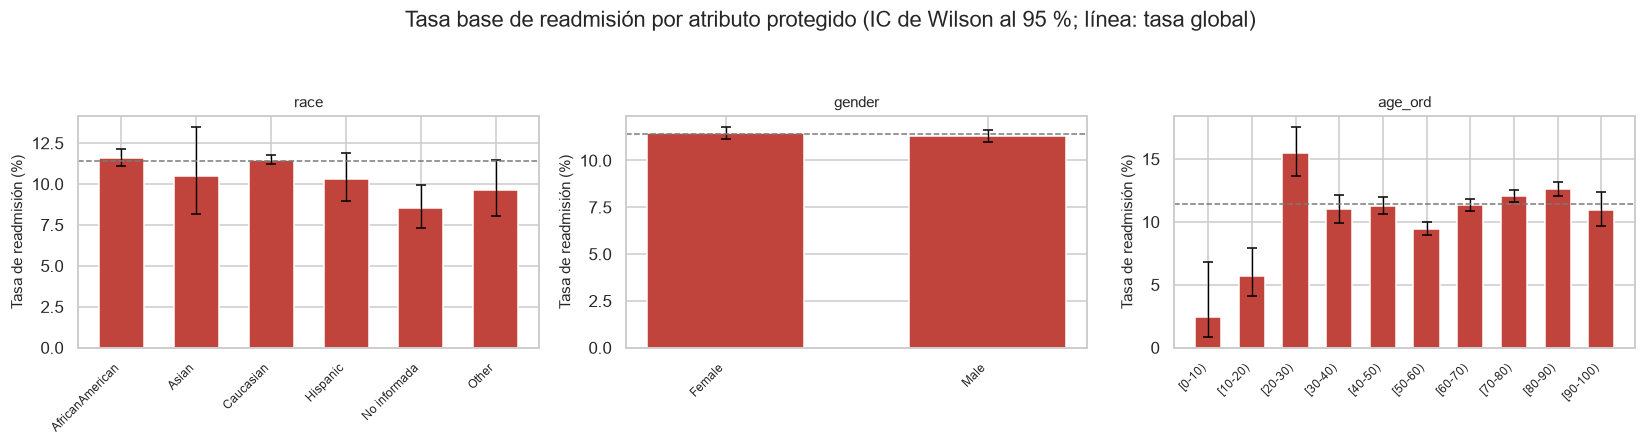

### Tasas base por atributo protegido

In [16]:
PROTEGIDOS = ["race", "gender", "age_ord"]

filas = []
for columna in PROTEGIDOS:
    for categoria, grupo in train.groupby(columna, observed=True):
        inferior, superior = intervalo_wilson(grupo[OBJETIVO].sum(), len(grupo))
        etiqueta = (ETIQUETAS_EDAD.get(categoria, categoria)
                    if columna == "age_ord" else categoria)
        filas.append({
            "atributo": columna,
            "grupo": etiqueta,
            "encuentros": len(grupo),
            "% de la cohorte": 100 * len(grupo) / len(train),
            "tasa (%)": 100 * grupo[OBJETIVO].mean(),
            "IC 95 % inferior": 100 * inferior,
            "IC 95 % superior": 100 * superior,
        })

equidad = pd.DataFrame(filas).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, columna in zip(axes, PROTEGIDOS):
    sub = equidad[equidad["atributo"] == columna]
    posiciones = np.arange(len(sub))
    ax.bar(posiciones, sub["tasa (%)"], color=PALETA[1], width=0.6)
    ax.errorbar(posiciones, sub["tasa (%)"],
                yerr=[sub["tasa (%)"] - sub["IC 95 % inferior"],
                      sub["IC 95 % superior"] - sub["tasa (%)"]],
                fmt="none", ecolor="black", elinewidth=0.9, capsize=3)
    ax.axhline(tasa_global, ls="--", color=GRIS, lw=1)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(sub["grupo"], fontsize=8, rotation=45, ha="right")
    ax.set_ylabel("Tasa de readmisión (%)")
    ax.set_title(columna, fontsize=10)
fig.suptitle("Tasa base de readmisión por atributo protegido "
             "(IC de Wilson al 95 %; línea: tasa global)", y=1.06)
plt.tight_layout()
plt.show()

por_raza = equidad[equidad["atributo"] == "race"]
anotar("c4_raza_rango",
       f"{por_raza['tasa (%)'].min():.1f} y {por_raza['tasa (%)'].max():.1f}")
anotar("c4_raza_min_n", f"{por_raza['encuentros'].min():,}")
guardar_resultado(equidad, "tasas_por_atributo_protegido")
tabla(equidad, filas=25, titulo="Tasas base por atributo protegido",
      indice=False)

Las tasas base por grupo racial se mueven entre el {glue:text}`c4_raza_rango` %, y el grupo más pequeño reúne {glue:text}`c4_raza_min_n` encuentros, lo que hace que su intervalo sea ancho. Ninguna diferencia es grande en términos absolutos, pero conviene registrarlas por escrito: son la línea de comparación contra la que la sección 7.6 mide la paridad del modelo base y el capítulo 10 la del modelo final.

Merece una nota la categoría de raza no informada, que presenta la tasa más baja del bloque. La ausencia del dato no es, por tanto, aleatoria respecto al desenlace, y eso justifica una vez más la decisión del capítulo 2 de tratarla como categoría propia en lugar de imputar la moda: imputar habría atribuido a esos encuentros el perfil del grupo mayoritario y habría borrado una diferencia real.

Por edad la variación es mayor, pero **no es monótona**, lo que conviene decir explícitamente porque contradice la intuición. El grupo de 20 a 30 años tiene una de las tasas más altas de toda la cohorte, por encima de la de los mayores de 80. La explicación plausible es de composición —a esa edad predomina la diabetes tipo 1, con descompensaciones agudas y reingresos frecuentes—, pero el conjunto de datos no registra el tipo de diabetes, así que queda como hipótesis y no como conclusión. Conviene recordar además la advertencia del capítulo 3: los grupos etarios extremos tienen muy pocos encuentros, de modo que sus tasas son estimaciones inestables.

Un apunte metodológico necesario para el cierre: la magnitud pequeña de las diferencias marginales por raza **no autoriza a concluir que el modelo será equitativo**. La ausencia de asociación marginal no implica ausencia de disparidad en las predicciones, porque el modelo puede reconstruir el atributo a partir de otras variables correlacionadas con él. La comprobación tiene que hacerse sobre las predicciones, no sobre los datos.

## 4.9. Síntesis del capítulo

In [17]:
sintesis = pd.DataFrame([
    ("Predictor numérico más asociado",
     f"{asociacion_num.index[0]} (delta de Cliff "
     f"{asociacion_num['delta de Cliff'].iloc[0]:.3f}, AUC univariado "
     f"{asociacion_num['AUC univariado'].iloc[0]:.3f})"),
    ("Predictor categórico más asociado",
     f"{asociacion_cat.index[0]} (V de Cramér "
     f"{asociacion_cat['V de Cramér'].iloc[0]:.3f})"),
    ("Predictor más informativo en conjunto",
     f"{ranking.index[0]}, con el "
     f"{ranking['% de la entropía del desenlace'].iloc[0]:.2f} % de la "
     "entropía del desenlace"),
    ("Significancia frente a relevancia",
     f"{(asociacion_num['significativa (Holm)'] == 'Sí').sum()} de "
     f"{len(asociacion_num)} contrastes numéricos sobreviven Holm; "
     f"{(asociacion_num['magnitud del efecto'] != 'Insignificante').sum()} "
     "alcanzan siquiera un efecto pequeño"),
    ("Efecto de la corrección múltiple",
     f"{len(perdidas)} variables categóricas pierden la significancia al "
     f"corregir: {', '.join(perdidas.index) if len(perdidas) else 'ninguna'}"),
    ("Forma de la asociación",
     f"De {int(examinadas.sum())} relaciones examinadas, "
     f"{(forma['forma'] == 'Monótona y lineal en el logit').sum()} son "
     "lineales en el logit y "
     f"{(forma['forma'] == 'Monótona con curvatura').sum()} tienen curvatura; "
     f"{(forma['forma'] == 'No monótona').sum()} no son monótonas"),
    ("Supuestos de chi²",
     f"{len(incumplen)} variables incumplen el supuesto de frecuencias "
     f"esperadas ({', '.join(incumplen.index) if len(incumplen) else '—'}); "
     f"{(incumplen['significativa (Holm)'] == 'Sí').sum()} de ellas son "
     "significativas, así que ninguna conclusión depende de ellas"),
    ("Interacciones",
     f"{(interacciones['información de interacción'] > 0).sum()} de "
     f"{len(interacciones)} pares muestran sinergia; la mayor aporta el "
     f"{100 * interacciones['información de interacción'].max() / entropia_objetivo:.3f} % "
     "de la entropía"),
    ("Control glucémico",
     f"Discrimina el hecho de medir, no el valor medido: "
     f"{sin_medir['tasa (%)']:.2f} % sin medición frente a "
     f"{medida['tasa (%)'].min():.2f}-{medida['tasa (%)'].max():.2f} % entre "
     f"los niveles medidos (V de Cramér "
     f"{asociacion_cat.loc['A1Cresult', 'V de Cramér']:.3f})"),
    ("Robustez a la dependencia",
     f"El AUC univariado se desplaza como mucho "
     f"{sensibilidad['diferencia absoluta en AUC'].max():.4f} al usar un "
     "encuentro por paciente; ninguna conclusión cambia"),
    ("Equidad",
     f"Tasas base por grupo racial entre "
     f"{por_raza['tasa (%)'].min():.1f} % y {por_raza['tasa (%)'].max():.1f} %; "
     "quedan como línea de comparación para el modelo final"),
    ("Expectativa de desempeño",
     f"Ningún predictor individual supera un AUC de "
     f"{ranking['AUC univariado'].abs().max():.3f}. Esa es la referencia que "
     "los modelos deben batir; la sinergia disponible es pequeña, así que "
     "cabe esperar una mejora de unas centésimas y no un salto cualitativo"),
], columns=["Dimensión", "Hallazgo"])

guardar_resultado(sintesis, "sintesis_bivariado")
tabla(sintesis, filas=15, titulo="Síntesis del análisis bivariado", indice=False)

### Síntesis del análisis bivariado

El capítulo deja fijadas tres cosas que el resto del proyecto debe respetar. La primera es una **expectativa cuantificada**: el mejor predictor individual alcanza un AUC de {glue:text}`c4_top_auc`, y esa es la referencia contra la que hay que juzgar los modelos, no el 0.5 del azar. La segunda es una **hipótesis falsable** sobre qué familia de modelos debería ganar y por qué. La tercera es una **línea de partida de equidad** contra la que medir el modelo final.

El capítulo 5 cierra la fase exploratoria revisando la redundancia entre predictores, la ausencia de fuga de información y el techo de desempeño que este conjunto de datos permite esperar.